# Step 1. Introduction & LSTM Forecasting Objective

In the previous notebook, machine learning models were used to forecast Rossmann store sales using store characteristics, promotions, holidays, competition information, and date-based features.

In this notebook, we will use a Long Short-Term Memory (LSTM) neural network for time-series forecasting. LSTM is designed to learn patterns from sequential data and can capture temporal relationships such as trends, seasonality, and previous sales patterns.

The objective of this notebook is to prepare the Rossmann sales data as a time series, analyze its stationarity, study autocorrelation using ACF and PACF, transform the data into supervised learning sequences, and train a 2-layer LSTM model.

The LSTM model will be evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE), and its performance will later be compared with the machine learning model developed in Notebook 2.


# Step 2. Import Libraries & Load Data

We first import the libraries required for time-series analysis, visualization, statistical testing, LSTM modelling, evaluation, and logging.

The Rossmann datasets are then loaded so that the historical sales data can be prepared for time-series forecasting.


In [ ]:
import os
import logging
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Logging configuration
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

logging.info("Libraries imported successfully.")

In [ ]:
train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")
store_df = pd.read_csv("../data/store.csv")

logging.info("Datasets loaded successfully.")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Store shape:", store_df.shape)

Train shape: (1017209, 9)
Test shape: (41088, 8)
Store shape: (1115, 10)


In [ ]:
train_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


Observation
* The training dataset contains 1,017,209 records with 9 columns.
* The test dataset contains 41,088 records with 8 columns.
* The store dataset contains 1,115 stores with 10 store-level attributes.
* Date is available in the training data and will be used as the main time-series index.
* Sales is our target variable for forecasting.

# Step 3. Prepare Time-Series Data

For LSTM forecasting, the sales data needs to be converted into a chronological time series.

Since Rossmann contains sales records for multiple stores, we will aggregate the daily sales across all stores. This gives us one overall daily sales value for each date.

Before modelling, we will check the date range, duplicate dates, and missing dates to make sure the time series is continuous and properly ordered.


## Convert Date and aggregate daily sales

In [ ]:
# Convert Date to datetime
train_df["Date"] = pd.to_datetime(train_df["Date"])

# Aggregate sales across all stores for each day
daily_sales = (
    train_df.groupby("Date", as_index=False)["Sales"]
    .sum()
    .sort_values("Date")
)

# Set Date as index
daily_sales = daily_sales.set_index("Date")

logging.info("Daily sales time series created successfully.")

print("Daily time series shape:", daily_sales.shape)
print("\nFirst 5 records:")
display(daily_sales.head())

print("\nLast 5 records:")
display(daily_sales.tail())

Daily time series shape: (942, 1)

First 5 records:


,Sales
Date,
2013-01-01,97235
2013-01-02,6949829
2013-01-03,6347820
2013-01-04,6638954
2013-01-05,5951593



Last 5 records:


,Sales
Date,
2015-07-27,10707292
2015-07-28,9115073
2015-07-29,8499962
2015-07-30,8798854
2015-07-31,10109742


## Check date range

In [ ]:
print("Start Date:", daily_sales.index.min())
print("End Date:", daily_sales.index.max())
print("Number of Days:", len(daily_sales))

Start Date: 2013-01-01 00:00:00
End Date: 2015-07-31 00:00:00
Number of Days: 942


## Check missing dates

In [ ]:
full_date_range = pd.date_range(
    start=daily_sales.index.min(),
    end=daily_sales.index.max(),
    freq="D"
)

missing_dates = full_date_range.difference(daily_sales.index)

print("Expected number of calendar days:", len(full_date_range))
print("Actual number of dates:", len(daily_sales))
print("Missing dates:", len(missing_dates))

if len(missing_dates) > 0:
    print("\nFirst missing dates:")
    print(missing_dates[:10])
else:
    print("\nNo missing dates found.")

Expected number of calendar days: 942
Actual number of dates: 942
Missing dates: 0

No missing dates found.


## Check duplicate dates

In [ ]:
duplicate_dates = daily_sales.index.duplicated().sum()

print("Duplicate dates:", duplicate_dates)

Duplicate dates: 0


## Plot daily sales

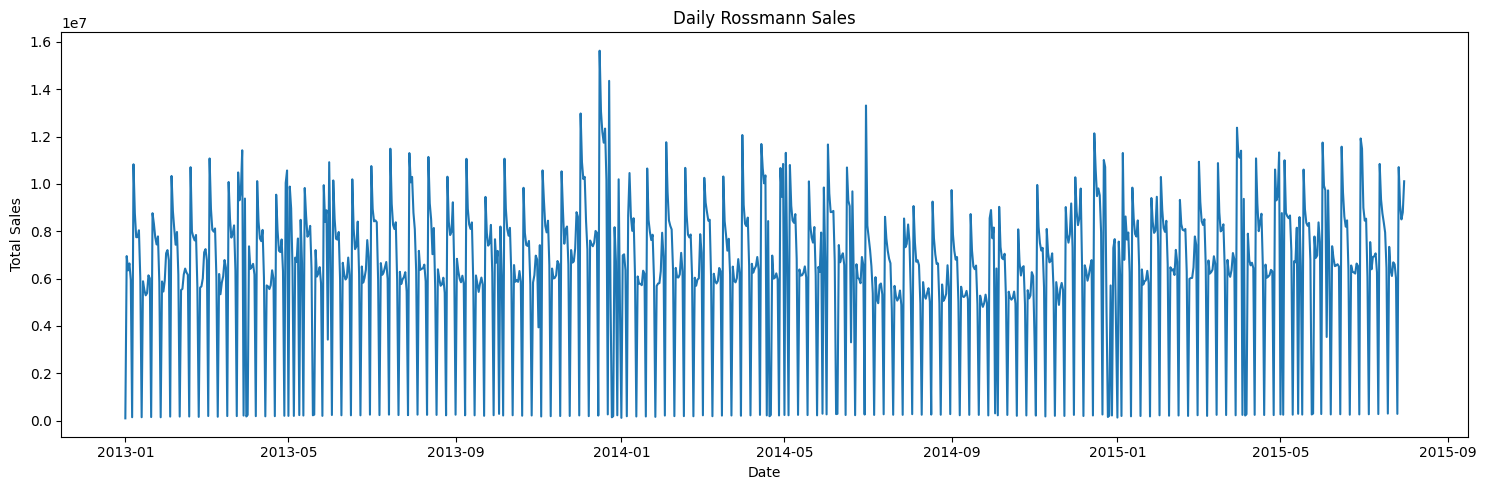

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(daily_sales.index, daily_sales["Sales"])

plt.title("Daily Rossmann Sales")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

Observation
* Daily aggregation produced 942 daily observations from 2013-01-01 to 2015-07-31.
* The time series contains no missing dates and no duplicate dates.
* The plot shows strong fluctuations in daily sales, including repeated sharp drops and peaks.
* The repeated pattern suggests that weekly/seasonal effects may be present in the sales data.
* Sales also show changes in their level over time, so we need to check whether the series is stationary before applying LSTM modelling.

# Step 4. Stationarity Analysis

Before applying time-series forecasting techniques, it is important to check whether the sales series is stationary.

A stationary time series has relatively stable statistical properties such as its mean and variance over time. Since the Rossmann sales series shows strong fluctuations, we will examine its rolling mean and rolling standard deviation.

We will also perform the Augmented Dickey-Fuller (ADF) test. The ADF test helps determine whether the time series has a unit root and therefore whether differencing may be required.


## Calculate rolling statistics

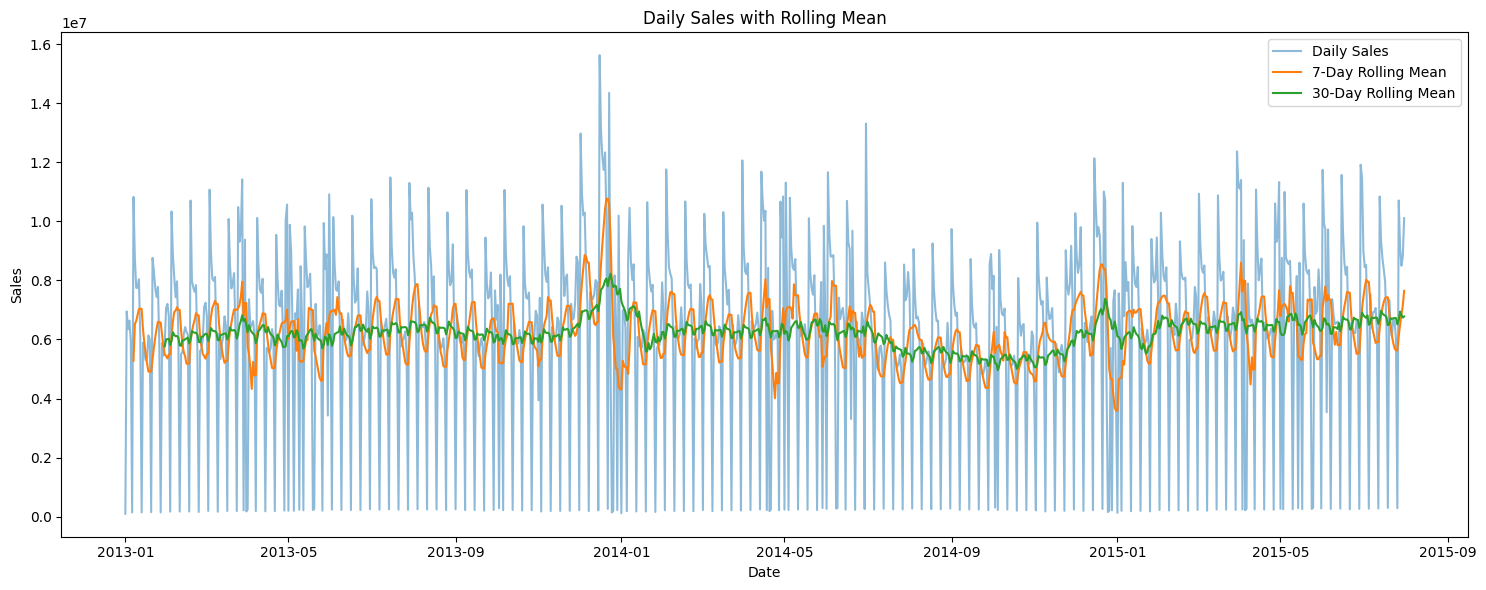

In [ ]:
sales_series = daily_sales["Sales"]

# Rolling mean and standard deviation
rolling_mean_7 = sales_series.rolling(window=7).mean()
rolling_std_7 = sales_series.rolling(window=7).std()

rolling_mean_30 = sales_series.rolling(window=30).mean()
rolling_std_30 = sales_series.rolling(window=30).std()

plt.figure(figsize=(15, 6))

plt.plot(
    sales_series,
    label="Daily Sales",
    alpha=0.5
)

plt.plot(
    rolling_mean_7,
    label="7-Day Rolling Mean"
)

plt.plot(
    rolling_mean_30,
    label="30-Day Rolling Mean"
)

plt.title("Daily Sales with Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.tight_layout()
plt.show()

## Rolling standard deviation

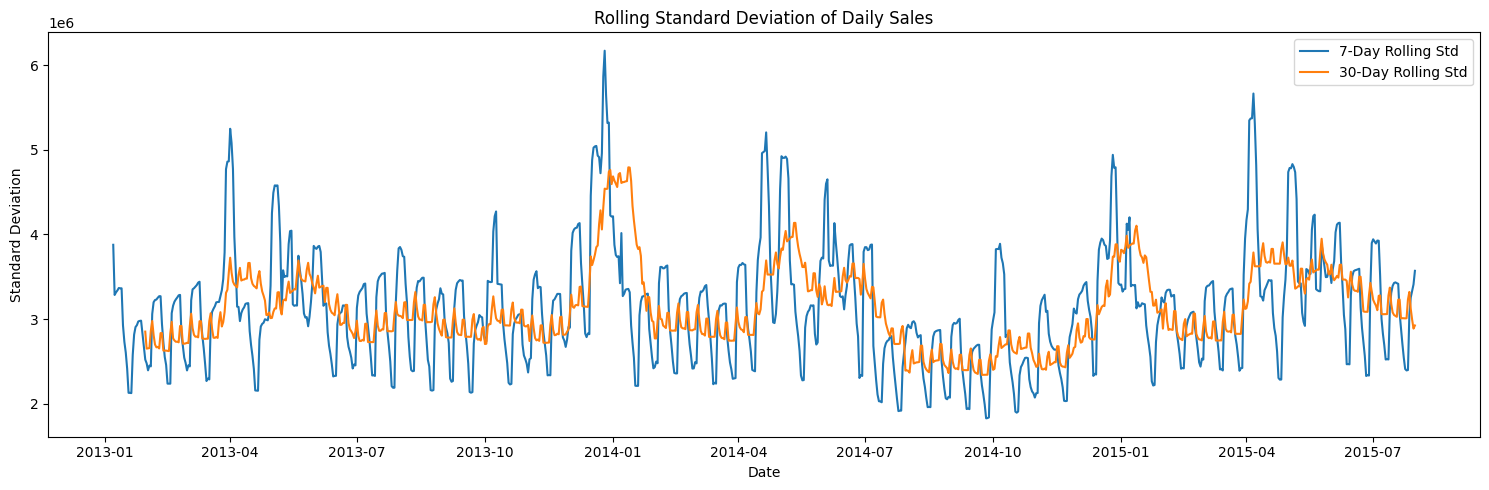

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(
    rolling_std_7,
    label="7-Day Rolling Std"
)

plt.plot(
    rolling_std_30,
    label="30-Day Rolling Std"
)

plt.title("Rolling Standard Deviation of Daily Sales")
plt.xlabel("Date")
plt.ylabel("Standard Deviation")
plt.legend()

plt.tight_layout()
plt.show()

## Augmented Dickey-Fuller Test

In [ ]:
adf_result = adfuller(sales_series.dropna())

adf_statistic = adf_result[0]
p_value = adf_result[1]
used_lags = adf_result[2]
observations = adf_result[3]

print("ADF Statistic:", adf_statistic)
print("p-value:", p_value)
print("Number of Lags:", used_lags)
print("Number of Observations:", observations)

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

if p_value < 0.05:
    print("\nResult: The series is stationary.")
else:
    print("\nResult: The series is non-stationary.")

ADF Statistic: -4.761614524595615
p-value: 6.436731330559343e-05
Number of Lags: 20
Number of Observations: 921

Critical Values:
1%: -3.437470108019385
5%: -2.8646832620852853
10%: -2.5684436698650503

Result: The series is stationary.


Observation

* The 7-day and 30-day rolling statistics show fluctuations in the sales series over time.
* The Augmented Dickey-Fuller (ADF) test produced a p-value of 6.44 × 10⁻⁵, which is below the 0.05 significance level.
* The ADF statistic (-4.76) is also lower than the critical values at the 1%, 5%, and 10% significance levels.
* Therefore, the null hypothesis of a unit root is rejected, indicating that the daily aggregated sales series is stationary.
* Since the series is already stationary, differencing is not required before proceeding with the LSTM preparation.

# Step 5. Differencing

Differencing is applied when a time series is non-stationary. Since the ADF test in Step 4 confirmed that the sales series is already stationary (p-value < 0.05), differencing is not required. Therefore, the original sales series will be retained for LSTM preparation.

In [ ]:
if p_value < 0.05:
    print("The sales series is already stationary.")
    print("Differencing is not required.")

    sales_for_lstm = sales_series.copy()

else:
    print("The sales series is non-stationary.")
    print("Applying first-order differencing...")

    sales_for_lstm = sales_series.diff().dropna()

print("\nSeries used for LSTM:")
display(sales_for_lstm.head())

print("\nNumber of observations:", len(sales_for_lstm))

The sales series is already stationary.
Differencing is not required.

Series used for LSTM:


,Sales
Date,
2013-01-01,97235
2013-01-02,6949829
2013-01-03,6347820
2013-01-04,6638954
2013-01-05,5951593



Number of observations: 942


# Step 6. ACF & PACF Analysis

Since the sales series is already stationary, we can now examine its autocorrelation structure. ACF shows how strongly current sales are related to previous sales at different lags, while PACF shows the direct relationship between sales and a specific lag after removing the effects of shorter lags.

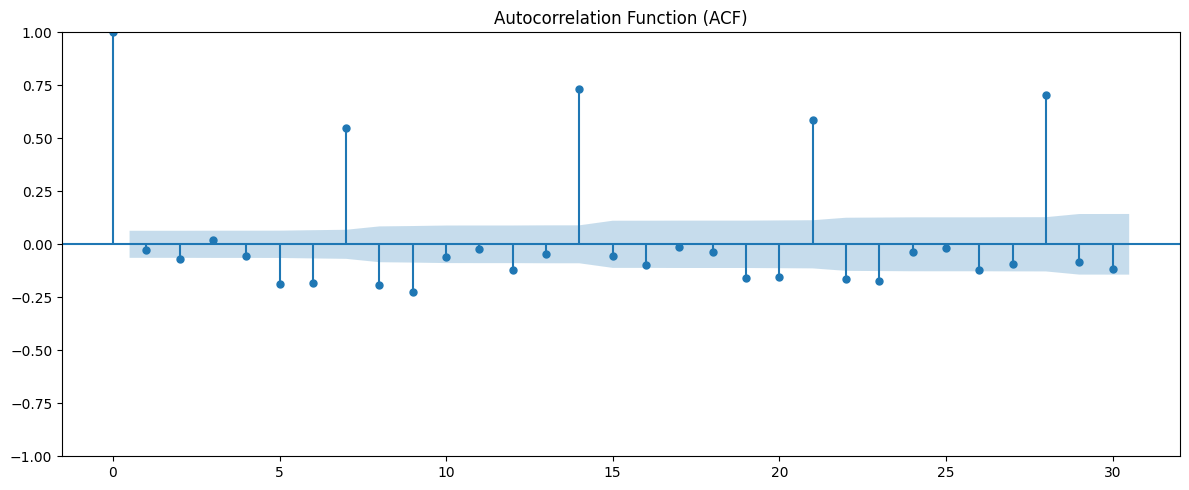

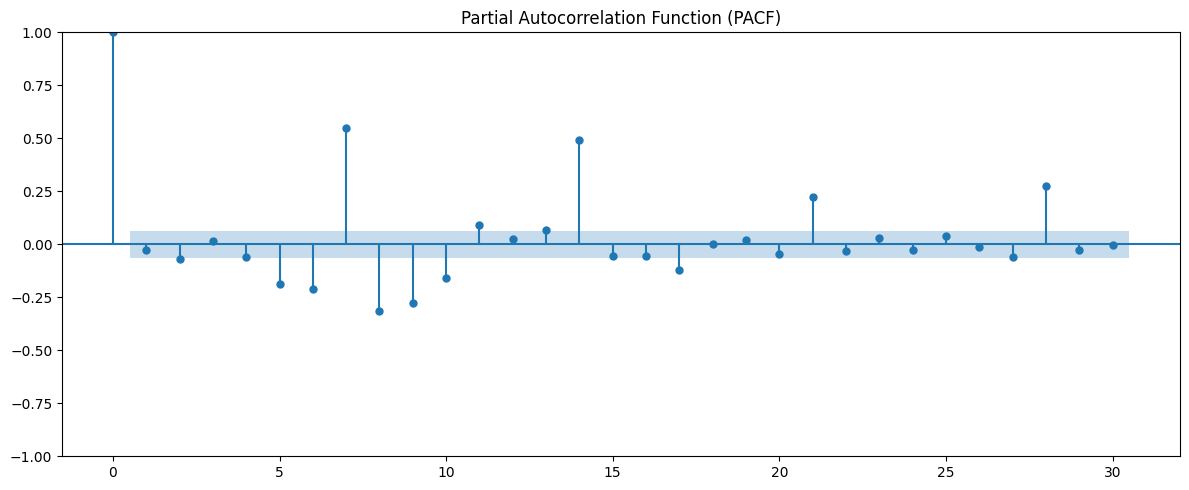

In [ ]:
plt.figure(figsize=(12, 5))
plot_acf(sales_for_lstm.dropna(), lags=30, ax=plt.gca())
plt.title("Autocorrelation Function (ACF)")
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 5))
plot_pacf(sales_for_lstm.dropna(), lags=30, ax=plt.gca(), method="ywm")
plt.title("Partial Autocorrelation Function (PACF)")
plt.tight_layout()
plt.show()

## Numerical ACF & PACF Values

In [ ]:
from statsmodels.tsa.stattools import acf, pacf

series_for_acf = sales_for_lstm.dropna()

acf_values = acf(series_for_acf, nlags=30)
pacf_values = pacf(series_for_acf, nlags=30, method="ywm")

acf_pacf_df = pd.DataFrame({
    "Lag": range(31),
    "ACF": acf_values,
    "PACF": pacf_values
})

display(acf_pacf_df.round(3))

,Lag,ACF,PACF
0,0,1.000,1.000
1,1,-0.025,-0.025
2,2,-0.071,-0.071
3,3,0.021,0.018
4,4,-0.057,-0.061
5,5,-0.186,-0.188
6,6,-0.181,-0.210
7,7,0.547,0.547
8,8,-0.191,-0.312
9,9,-0.226,-0.278


Observation
* The ACF shows strong positive correlation at lag 7 (0.547), indicating a clear weekly pattern in daily sales.
* Stronger positive correlation is also visible at lag 14 (0.732), lag 21 (0.588), and lag 28 (0.704), further supporting a repeating weekly seasonal pattern.
* PACF also shows notable values at lag 7 (0.547) and lag 14 (0.491).
* Therefore, the sales series contains weekly seasonal dependence, meaning previous days—especially values around previous weeks—can provide useful information for forecasting.
* These sequential dependencies make an LSTM model suitable for capturing temporal patterns.

# Step 7. Supervised Learning Transformation

Based on the ACF and PACF analysis, we observed a strong weekly pattern in the sales data. To allow the LSTM model to learn this temporal pattern, we transform the continuous time series into input sequences and target values. We use the previous 7 days of sales as input and the next day’s sales as the target. This 7-day look-back window is chosen because the sales data shows weekly seasonal dependence.

## Define Look-back Window

In [ ]:
# Define look-back window
look_back = 7

print("Look-back window:", look_back, "days")
print("The model will use the previous 7 days to predict the next day.")

Look-back window: 7 days
The model will use the previous 7 days to predict the next day.


## Create LSTM Sequences

Now we convert the daily sales series into supervised-learning sequences. With a 7-day look-back, every input contains the previous 7 days of sales, and the target is the sales value of the following day.

In [ ]:
# Create supervised sequences for LSTM

def create_sequences(data, look_back):
    X, y = [], []

    for i in range(look_back, len(data)):
        X.append(data[i - look_back:i])
        y.append(data[i])

    return np.array(X), np.array(y)


sales_values = sales_for_lstm.values

X, y = create_sequences(sales_values, look_back)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (935, 7)
y shape: (935,)


## Reshape Data for LSTM

In [ ]:
X = X.reshape((X.shape[0], X.shape[1], 1))

print("X shape after reshaping:", X.shape)
print("y shape:", y.shape)

X shape after reshaping: (935, 7, 1)
y shape: (935,)


## Chronological Train-Validation Split

In [ ]:
split_index = int(len(X) * 0.80)

X_train = X[:split_index]
X_val = X[split_index:]

y_train = y[:split_index]
y_val = y[split_index:]

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

print("\nX_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

print("\ny_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

Training samples: 748
Validation samples: 187

X_train shape: (748, 7, 1)
X_val shape: (187, 7, 1)

y_train shape: (748,)
y_val shape: (187,)


Observation

* A 7-day look-back window generated 935 sequences from the 942 daily observations.
* The chronological split produced 748 training sequences and 187 validation sequences.
* Each LSTM input has the shape (7, 1), representing 7 previous days with one feature: Sales.
* The data was split chronologically without random shuffling, preserving the time-series order.

# Step 8. Data Scaling

LSTM models generally perform better when numerical values are scaled to a smaller range.

For this, we will use MinMaxScaler with a range of (-1, 1).

To avoid data leakage, the scaler will be fitted only on the training data. The same scaler will then be used to transform both training and validation data.

## Scale the Sales Data

In [ ]:
# Step 8: Scale data using MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))

# Fit scaler only on training data
scaler.fit(y_train.reshape(-1, 1))

# Scale training and validation target values
y_train_scaled = scaler.transform(
    y_train.reshape(-1, 1)
).flatten()

y_val_scaled = scaler.transform(
    y_val.reshape(-1, 1)
).flatten()

# Scale input sequences using the same scaler
X_train_scaled = scaler.transform(
    X_train.reshape(-1, 1)
).reshape(X_train.shape)

X_val_scaled = scaler.transform(
    X_val.reshape(-1, 1)
).reshape(X_val.shape)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_val_scaled shape:", X_val_scaled.shape)

print("y_train_scaled shape:", y_train_scaled.shape)
print("y_val_scaled shape:", y_val_scaled.shape)

print("\nScaled training range:")
print("Minimum:", X_train_scaled.min())
print("Maximum:", X_train_scaled.max())

X_train_scaled shape: (748, 7, 1)
X_val_scaled shape: (187, 7, 1)
y_train_scaled shape: (748,)
y_val_scaled shape: (187,)

Scaled training range:
Minimum: -1.0026923453961964
Maximum: 1.0


Observation
* MinMaxScaler was applied using the range (-1, 1).
* The scaler was fitted using training data only, avoiding data leakage.
* Training and validation sequences retain the required LSTM shape of (samples, 7, 1).
* The scaled data is now ready for LSTM model training.

# Step 9. Build the LSTM Model
Now that the sales data has been converted into 7-day input sequences and scaled, we can build the LSTM model. The model will learn the relationship between the previous 7 days of sales and the next day’s sales. We use two LSTM layers so the model can learn temporal patterns from the sequence before producing the final next-day sales prediction through the Dense layer.

In [ ]:
model = Sequential([
    LSTM(
        64,
        return_sequences=True,
        input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2])
    ),

    Dropout(0.2),

    LSTM(32),

    Dropout(0.2),

    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 7, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

Observation
* The model contains two LSTM layers with 64 and 32 units.
* The first LSTM returns sequences so the second LSTM can process the temporal information.
* Dropout (20%) is included after each LSTM layer to help reduce overfitting.
* The final Dense layer has 1 output, representing the predicted next-day sales.
* Total trainable parameters: 29,345.

# Step 10. Train the LSTM Model
Now that the LSTM architecture is ready, we train it using the historical training sequences. The model learns the relationship between the previous 7 days of sales and the next day's sales by repeatedly adjusting its weights to reduce the prediction error.

We allow the model to train for a maximum of 50 epochs, using a batch size of 32. Since training for all 50 epochs may not be necessary, EarlyStopping monitors the validation loss and stops training when the model stops improving. restore_best_weights=True ensures that the model keeps the best-performing weights observed during training.

Because this is a time-series problem, we use shuffle=False so that the chronological order of the training sequences is preserved.

## Model Training with Early Stopping

In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    shuffle=False,
    verbose=1
)

Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.1680 - val_loss: 0.1837
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1619 - val_loss: 0.1761
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1597 - val_loss: 0.1718
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1531 - val_loss: 0.1662
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1394 - val_loss: 0.1357
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1245 - val_loss: 0.1124
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.1134 - val_loss: 0.1110
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0974 - val_loss: 0.1024
Epoch 9/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0960 - val_loss: 0.0990
Epoch 10/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0912 - val_loss: 0.0960
Epoch 11/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0893 - val_loss: 0.0921
Epoch 12/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0

## Loss Curves

The training and validation loss curves help us observe how the LSTM learned over the epochs and whether validation performance started to deteriorate.

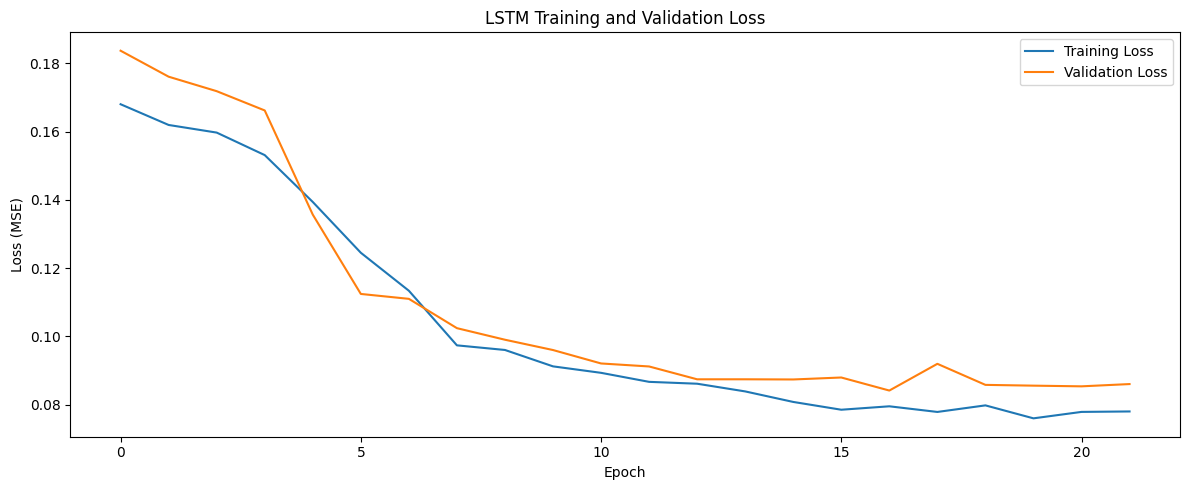

Best Epoch: 17
Best Validation Loss: 0.08414530754089355
Total Epochs Trained: 22


In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.tight_layout()
plt.show()

best_epoch = np.argmin(history.history["val_loss"]) + 1
best_val_loss = min(history.history["val_loss"])

print("Best Epoch:", best_epoch)
print("Best Validation Loss:", best_val_loss)
print("Total Epochs Trained:", len(history.history["loss"]))

Observation
* Training loss decreased from 0.1680 → 0.0780, showing that the model learned the training patterns.
* Validation loss decreased from 0.1837 → 0.0841 at its best point.
* The best validation performance occurred at Epoch 17.
* After Epoch 17, validation loss did not improve consistently, so EarlyStopping stopped training at Epoch 22.

# Step 11. Forecasting & Evaluation

The trained LSTM will now generate predictions for the validation period. Since the model was trained on scaled sales values, the predictions will first be converted back to the original Sales scale. We will then evaluate the model using MAE and RMSE and compare actual sales with predicted sales.

## Generate Predictions

In [ ]:
y_pred_scaled = model.predict(X_val_scaled)

print("Predicted values shape:", y_pred_scaled.shape)
print("Actual values shape:", y_val_scaled.shape)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step
Predicted values shape: (187, 1)
Actual values shape: (187,)


## Inverse Scaling

In [ ]:
y_pred = scaler.inverse_transform(y_pred_scaled).flatten()

y_actual = scaler.inverse_transform(
    y_val_scaled.reshape(-1, 1)
).flatten()

print("Original-scale prediction range:")
print("Minimum:", y_pred.min())
print("Maximum:", y_pred.max())

print("\nOriginal-scale actual range:")
print("Minimum:", y_actual.min())
print("Maximum:", y_actual.max())

Original-scale prediction range:
Minimum: -295443.94
Maximum: 7891585.0

Original-scale actual range:
Minimum: 199419.0000000002
Maximum: 12371453.0


## Calculate MAE and RMSE

In [ ]:
mae = mean_absolute_error(y_actual, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_actual, y_pred)
)

print("LSTM Validation MAE:", mae)
print("LSTM Validation RMSE:", rmse)

LSTM Validation MAE: 1407623.2038613386
LSTM Validation RMSE: 2248894.2924033767


## Actual vs Predicted Plot

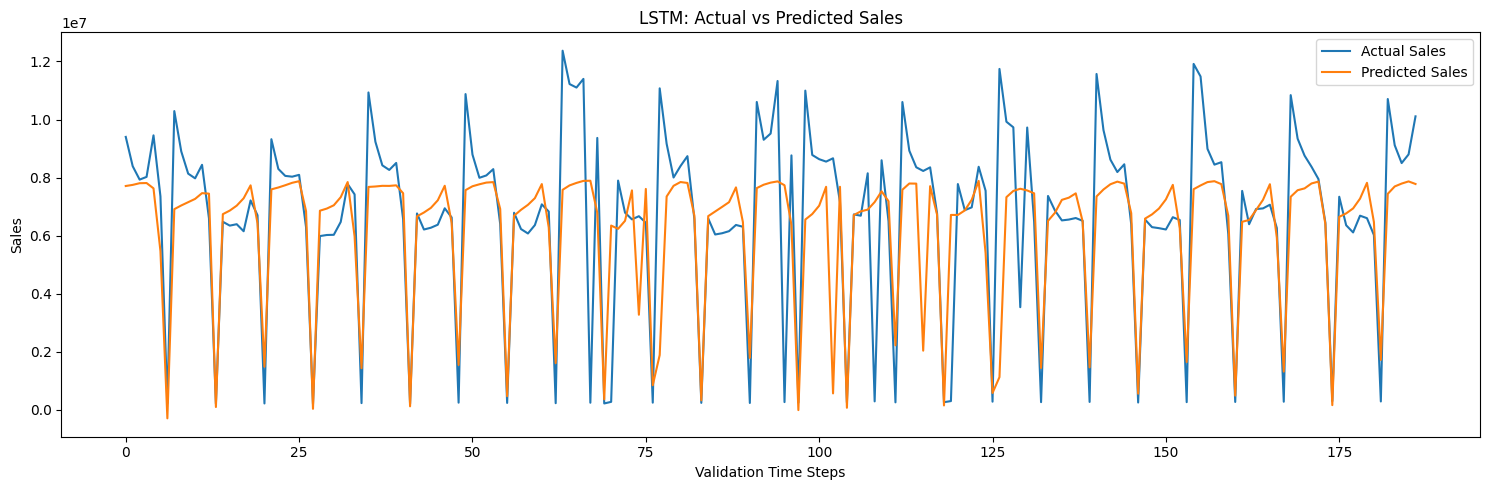

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(y_actual, label="Actual Sales")
plt.plot(y_pred, label="Predicted Sales")

plt.title("LSTM: Actual vs Predicted Sales")
plt.xlabel("Validation Time Steps")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()

Observation
* The LSTM generated predictions for 187 validation observations.
* Validation MAE = 1,407,623.20.
* Validation RMSE = 2,248,894.29.
* The actual validation sales ranged from approximately 199,419 to 12,371,453.
* The predictions ranged from approximately -295,444 to 7,891,585.
* The negative prediction is not realistic because Sales cannot be negative.  
* This indicates that the LSTM has difficulty modelling some of the sales variation, particularly at higher sales levels.
* The RMSE being higher than MAE indicates that some prediction errors are relatively large.

# Step 12. LSTM Model Analysis

The LSTM model has been trained and evaluated on the validation data. In this step, we will briefly analyze the prediction performance and understand whether the model is capturing the overall sales pattern.

We will focus only on the LSTM model here. The comparison with the Random Forest model will be performed later in Notebook 4.

In [ ]:
print("LSTM Model Analysis")
print("-" * 40)

print("Validation Samples:", len(y_actual))
print("MAE:", mae)
print("RMSE:", rmse)

print("\nPrediction Statistics:")
print("Actual Sales Mean:", y_actual.mean())
print("Predicted Sales Mean:", y_pred.mean())

print("\nPrediction Range:")
print("Actual Min:", y_actual.min())
print("Actual Max:", y_actual.max())
print("Predicted Min:", y_pred.min())
print("Predicted Max:", y_pred.max())

LSTM Model Analysis
----------------------------------------
Validation Samples: 187
MAE: 1407623.2038613386
RMSE: 2248894.2924033767

Prediction Statistics:
Actual Sales Mean: 6637506.481283423
Predicted Sales Mean: 6208441.5

Prediction Range:
Actual Min: 199419.0000000002
Actual Max: 12371453.0
Predicted Min: -295443.94
Predicted Max: 7891585.0


Observation
* 187 validation samples were evaluated.
* MAE: ~1.41M and RMSE: ~2.25M.
* Predicted average sales (6.21M) are lower than actual average sales (6.64M).
* The model underestimates high sales and produces some negative predictions.
* Overall, the LSTM captures the general pattern but has prediction errors.

# Step 13. Model Saving

The LSTM model has now been trained and evaluated, so we save the trained model and fitted scaler for future use. This allows us to reuse the model later without training it again. The saved files can also be loaded in Notebook 4 for final model comparison and test-set prediction.

In [ ]:
import os
import joblib

# Model saving directory
save_dir = "/content/drive/MyDrive/NextHikes-Project6"

# Create directory if it does not exist
os.makedirs(save_dir, exist_ok=True)

# File paths
model_path = os.path.join(save_dir, "final_lstm_model.keras")
scaler_path = os.path.join(save_dir, "lstm_scaler.pkl")

# Save LSTM model
model.save(model_path)

# Save scaler
joblib.dump(scaler, scaler_path)

print("LSTM model saved successfully:")
print(model_path)

print("\nLSTM scaler saved successfully:")
print(scaler_path)

# Step 14. Logging

Logging is already configured in Step 2. Here we record the major LSTM workflow events so that the notebook keeps track of model training, evaluation, and saving.

In [46]:
logging.info("LSTM model training completed.")
logging.info("LSTM validation evaluation completed.")
logging.info(f"LSTM Validation MAE: {mae:.2f}")
logging.info(f"LSTM Validation RMSE: {rmse:.2f}")
logging.info(f"LSTM model saved: {model_path}")
logging.info(f"LSTM scaler saved: {scaler_path}")

print("LSTM workflow logging completed.")

LSTM workflow logging completed.


Observation
* LSTM training, evaluation, and model-saving activities are recorded in the notebook log.
* The model and scaler paths are also recorded for future use.

# Step 15. Conclusion

* The LSTM model was developed to forecast daily Rossmann sales using historical sequential sales patterns.
* The sales time series was analyzed for stationarity and autocorrelation before model development.
* A 7-day look-back window was used to capture weekly sales patterns.
* The LSTM model achieved a validation MAE of approximately 1.41 million and RMSE of approximately 2.25 million.
* The trained LSTM model and scaler were saved for reuse.
* ML vs LSTM comparison and final model selection will be performed in Notebook 4.
* The final test prediction and submission file will also be prepared in Notebook